In [5]:
from scipy.io import loadmat
import spikeinterface as si
import RCP_analysis as rcp
from RCP_analysis.python.functions.config_loading import *

# Local reference params, both floats
RATES = PARAMS.NPRW_rate_est
BIN_MS = 20 #RATES.get("bin_ms")
SIGMA_MS = RATES.get("sigma_ms")
THRESH = RATES.get("detect_threshold")
MS_BEFORE = float(RATES.get("remove_ms_before"))
TAIL_MS = float(RATES.get("remove_tail_ms_after"))
WIN_MS = (-600.0, 600.0)

NPRW_CKPT_OUT = OUT_BASE.parent / 'results' / "checkpoints" / "NPRW"
        
global_job_kwargs = dict(n_jobs=PARAMS.parallel_jobs, chunk_duration=PARAMS.chunk)
si.set_global_job_kwargs(**global_job_kwargs)

In [6]:
INDEX = 1

# 2) Find sessions and load data from each Intan folder
sess_folders = rcp.list_intan_sessions(INTAN_ROOT)
print(f"Found Intan sessions: {len(sess_folders)}")

nprw_pp_folders = sorted(NPRW_CKPT_OUT.glob("pp_*"))
nprw_pp_folder = nprw_pp_folders[INDEX]
print(nprw_pp_folder)

nprw_peaks_folders = sorted(NPRW_CKPT_OUT.glob("rates__*.npz"))
nprw_peaks_folder = nprw_peaks_folders[INDEX]
print(nprw_peaks_folder)

# for sess in sess_folders[:]: # Can tweak here to isolate sessions
rec_nprw = si.load(nprw_pp_folder)

def _parse_SI_peaks(peaks, n_channels: int) -> tuple[dict[int, np.ndarray], dict[int, np.ndarray]]:
    peak_times: dict[int, np.ndarray] = {i: np.array([], dtype=np.int64) for i in range(n_channels)}
    peak_amp: dict[int, np.ndarray] = {i: np.array([], dtype=np.float32) for i in range(n_channels)}

    ch_idx = peaks["channel_index"]
    for i in np.unique(ch_idx):
        ii = int(i)
        if ii >= n_channels:
            continue
        m = (ch_idx == i)
        peak_times[ii] = peaks["sample_index"][m]
        peak_amp[ii] = peaks["amplitude"][m]

    return peak_times, peak_amp

nprw_peaks_si_obj = np.load(nprw_peaks_folder, allow_pickle=True)
nprw_peak_samps, nprw_peak_amps = _parse_SI_peaks(nprw_peaks_si_obj['peaks'], 128)
nprw_peak_ms   = {k: (v / 30000)   * 1000.0 for k, v in nprw_peak_samps.items()}

SESSION = nprw_peaks_si_obj['meta'].item()['session']

NPRW_SORT_CKPT_OUT = OUT_BASE / "checkpoints" / "sorting_results" / SESSION / "NPRW" / "folder_KS4"
NPRW_SORT_ANALYZE_CKPT_OUT = OUT_BASE / "checkpoints" / "sorting_results" / SESSION / "NPRW" / "my_sorting_analyzer"

PERI_ROOT = OUT_BASE / "checkpoints" / "PeriStim"
STIM_PERI_ROOT  = PERI_ROOT / "stim_reaches"

stim_dir = STIM_PERI_ROOT #/ 'target_A'

Found Intan sessions: 63
/media/bryan/Expansion/Nike/20260324_NRR_RW026/results/checkpoints/NPRW/pp_local_30_150__interp_NRR_RW026_260324_122125
/media/bryan/Expansion/Nike/20260324_NRR_RW026/results/checkpoints/NPRW/rates__NRR_RW026_260324_121810__bin50ms_sigma50ms.npz


In [7]:
# Jax imports
import jax
import jax.numpy as jnp
import jax.random as jr
import optax
import matplotlib.pyplot as plt
from jax import vmap, value_and_grad, jit
from jax.nn import softplus
from tensorflow_probability.substrates.jax.distributions import Poisson

from dynamax.generalized_gaussian_ssm import (
    ParamsGGSSM, GeneralizedGaussianSSM, EKFIntegrals,
    conditional_moments_gaussian_smoother as cmgs,
)
from dynamax.utils.utils import random_rotation

In [ ]:
import json
# Import control
CONTROL_PERI_ROOT  = PERI_ROOT / "control_reaches"
control_dir = CONTROL_PERI_ROOT # / 'target_A'
matches = list(control_dir.glob(f"peristim__NRR_RW*.npz"))
control_npz_path = matches[0]  # or iterate if multiple
control_npz = np.load(control_npz_path, allow_pickle=True)
event_ms = control_npz['event_ms']

session_name = nprw_pp_folder.name.split("NRR_RW", 1)[1]
matches = list(stim_dir.glob(f"peristim__NRR_RW{session_name}__BR_*.npz"))
stim_npz_path = matches[0]  # or iterate if multiple
stim_npz = np.load(stim_npz_path, allow_pickle=True)

counts_ch_stim = stim_npz['NPRW_counts']
centers_ms_stim = stim_npz["NPRW_rel_t"]
edges_ms_stim = stim_npz["NPRW_edges_ms"]
meta = json.loads(stim_npz['meta_json'].item())
stim_dur = meta["recording_stim_dur"]

# Get stim indices
n_trials_i, n_ch, n_bins = counts_ch_stim.shape
nprw_meta = json.loads(stim_npz["nprw_meta_json"].item())
stim_ch_0 = np.asarray(nprw_meta["stim_channels"], dtype=int) - 1
ir_idx = int(jnp.argmin(jnp.abs(centers_ms_stim)))
stim_ind_stim = jnp.zeros((n_trials_i, n_bins, n_ch))
stim_ind_stim = stim_ind_stim.at[:, ir_idx, stim_ch_0].set(1.0)

peak_ms_dedup_control = control_npz['NPRW_peak_ms_dedup']
if isinstance(peak_ms_dedup_control, np.ndarray) and peak_ms_dedup_control.dtype == object:
    peak_ms_dedup_control = peak_ms_dedup_control.item()
    
# Process control bin counts
counts_ch_control, centers_ms_control, edges_ms_control, left_bins_control = rcp.bin_counts_around_stim(
    peak_ms_dedup_control, BIN_MS, event_ms,
    MS_BEFORE, (stim_dur + TAIL_MS), WIN_MS
)

n_trials_i, n_ch, n_bins = counts_ch_control.shape
nprw_meta = json.loads(control_npz["nprw_meta_json"].item())
stim_ch_0 = np.asarray(nprw_meta["stim_channels"], dtype=int) - 1
ir_idx = int(jnp.argmin(jnp.abs(centers_ms_control)))
stim_ind_control = jnp.zeros((n_trials_i, n_bins, n_ch))
# stim_ind_control = stim_ind_control.at[:, ir_idx, stim_ch_0].set(0)

In [9]:
# z score per trial
mu = np.nanmean(counts_ch_control[:, :, :], axis=2, keepdims=True)
sig = np.nanstd (counts_ch_control[:, :, :], axis=2, keepdims=True)
sig = np.clip(sig, 1e-6, None)
counts_z = (counts_ch_control - mu) / sig
psth_z = np.nanmean(counts_z, axis=0)
X = psth_z
t = centers_ms_control

# Peak value and peak time (argmax) within the search window
X_finite = np.where(np.isfinite(X), X, -np.inf)
peak_idx = np.argmax(X_finite, axis=1)
peak_time_ms = t[peak_idx]
peak_val = np.max(X_finite, axis=1)

# Keep only neurons with a real response; rest go to bottom
z_thresh = 0  # tune (0.5–1.5 is common)
responsive = np.isfinite(peak_val) & (peak_val >= z_thresh)

order_resp = np.argsort(peak_time_ms[responsive])  # earliest first
order = np.concatenate([np.where(responsive)[0][order_resp],
                        np.where(~responsive)[0]])

psth_ch_sorted = psth_z[order]

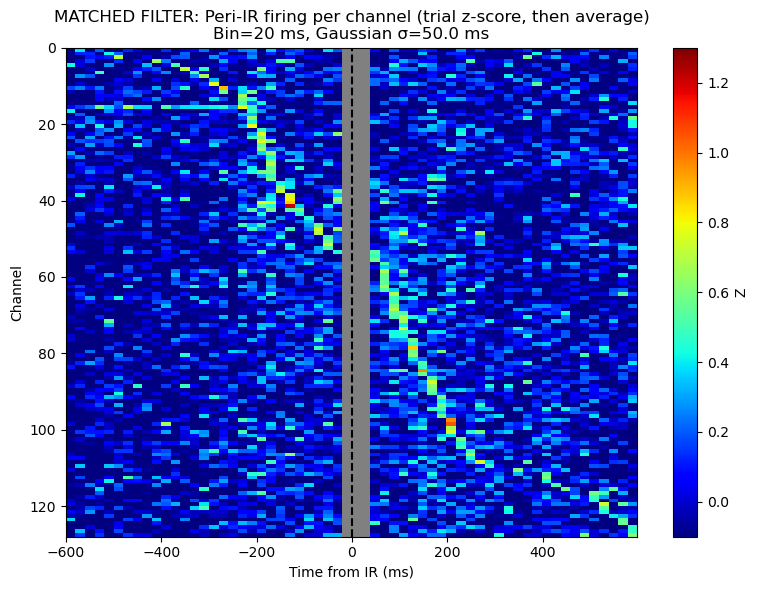

In [10]:
%matplotlib inline

def pad_bins_to_edges(Z, centers_ms, edges_ms, tol=1e-6):
    # Z: (n_ch, n_centers)
    # edges_ms: (n_edges,) -> expects Z to have (n_edges-1) columns
    centers_from_edges = 0.5 * (edges_ms[:-1] + edges_ms[1:])  # (n_edges-1,)
    out = np.full((Z.shape[0], centers_from_edges.size), np.nan, dtype=float)

    # map each provided center to the nearest edge-center
    idx = np.full(centers_ms.size, -1, dtype=int)
    for j, c in enumerate(centers_ms):
        k = int(np.argmin(np.abs(centers_from_edges - c)))
        if abs(centers_from_edges[k] - c) <= tol:
            idx[j] = k

    if np.any(idx < 0):
        bad = centers_ms[idx < 0]
        raise ValueError(f"Some centers did not match edge-centers (tol={tol}): {bad[:10]}")

    out[:, idx] = Z
    return out, centers_from_edges

psth_plot, centers_from_edges = pad_bins_to_edges(psth_ch_sorted, centers_ms_control, edges_ms_control, tol=1e-3)

# plot
n_ch = psth_plot.shape[0]
y_edges = np.arange(n_ch + 1)

fig, ax = plt.subplots(figsize=(8,6))
ax.set_facecolor("0.5")
pc = ax.pcolormesh(
    edges_ms_control,
    y_edges,
    psth_plot,
    shading="flat",
    cmap="jet",
    vmin=-0.1,
    vmax=1.3,
)

ax.invert_yaxis()
ax.axvline(0, linestyle="--", color="black")
ax.set_ylim(n_ch, 0)
ax.set_xlabel("Time from IR (ms)")
ax.set_ylabel("Channel")
ax.set_title(f"MATCHED FILTER: Peri-IR firing per channel (trial z-score, then average)\nBin={BIN_MS} ms, Gaussian σ={SIGMA_MS} ms")
fig.colorbar(pc, ax=ax, label="Z")
plt.tight_layout()
plt.show()

## Concatenate control and stim data

In [11]:
labels_control = jnp.zeros(len(counts_ch_control), dtype=jnp.int32)   # 0 = control
labels_stim    = jnp.ones(len(counts_ch_stim),    dtype=jnp.int32)     # 1 = stim
trial_labels   = jnp.concatenate([labels_control, labels_stim], axis=0)  # shape: (n_trials_combined,)

stim_ind_combined = jnp.concatenate([stim_ind_control, stim_ind_stim], axis=0)
all_observations_combined = jnp.concatenate([counts_ch_control, counts_ch_stim], axis=0)
all_observations_combined = jnp.array(all_observations_combined.transpose(0, 2, 1))

In [12]:
stim_ind_combined.shape

(37, 57, 128)

## Fit together

In [13]:
key = jr.key(0)
key1, key2 = jr.split(key, 2)

state_dim = 4
num_trials, num_timesteps, n_ch = all_observations_combined.shape

In [14]:
# Initialization
C_init = 0.5 * jr.normal(key2, shape=(n_ch, state_dim)) # Initialize C to be random values
all_observations_control = jnp.array(counts_ch_control.transpose(0, 2, 1)) # Use control mean firing rate to initialize
d_init = jnp.mean(all_observations_control, axis=(0, 1))  # Average over trials and time steps for mean_rate_per_channel
log_d_init = jnp.log(d_init)
A_init = jnp.eye(state_dim)
B_init = jnp.zeros((state_dim, n_ch)) + 0.01 * jr.normal(key2, shape=(state_dim, n_ch))
theta = (C_init, log_d_init, A_init, B_init)

def make_params(C, d, A, B):
    return ParamsGGSSM(
        initial_mean=jnp.zeros(state_dim),
        initial_covariance=jnp.eye(state_dim),
        dynamics_function=lambda z, u: A @ z + B @ u,
        dynamics_covariance=0.001 * jnp.eye(state_dim),
        emission_mean_function=lambda z, u: softplus(C @ z + d),
        emission_cov_function=lambda z, u: jnp.diag(softplus(C @ z + d)),
        emission_dist=lambda mu, Sigma: Poisson(rate=mu),
    )

def loss_fn(theta, observations, inputs):
    """
    Compute the negative log-likelihood using EKF like integrals. This is the Conditional Marginal Gaussian Smoother (CMGS) objective, which is an approximation to the true marginal log-likelihood.

    Returns:
        Negative log-likelihood + penalty for stability
    """
    C, log_d, A, B = theta
    sigma_max = jnp.linalg.norm(A, ord=2)
    penalty_A = 1e2 * jnp.maximum(0.0, sigma_max - 1.0) ** 2 # Constraining the spectral norm of A to be less than 1 for stability
    
    # sigma_max = jnp.linalg.norm(B, ord=2)
    # penalty_B = 1e2 * jnp.maximum(0.0, sigma_max - 1.0) ** 2 # Constraining the spectral norm of B to be less than 1 for stability
    
    params = make_params(C, jnp.exp(log_d), A, B)
    posts = vmap(lambda obs, inp: cmgs(params, EKFIntegrals(), obs, inputs=inp))(observations, inputs)
    return -jnp.sum(posts.marginal_loglik) + penalty_A #+ penalty_B

optimizer = optax.adam(5e-3)
opt_state = optimizer.init(theta)

@jit
def step(theta, opt_state, observations, inputs):
    loss, grads = value_and_grad(loss_fn)(theta, observations, inputs)
    updates, new_opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(theta, updates)
    return params, new_opt_state, loss

losses = []
n_epochs = 500
for epoch in range(n_epochs):
    theta, opt_state, loss = step(theta, opt_state, all_observations_combined, stim_ind_combined)
    losses.append(float(loss))
    if epoch % 50 == 0:
        C_cur, log_d_cur, A_cur, B_cur = theta
        print(f"epoch {epoch:4d}  loss={loss:.2f}  B_norm={jnp.linalg.norm(B_cur):.4f}")

C_fit_combined, log_d_fit_combined, A_fit_combined, B_fit_combined = theta

print('singular values of A_fit:', jnp.linalg.svd(A_fit_combined, compute_uv=False))

epoch    0  loss=192169.11  B_norm=0.2399
epoch   50  loss=109395.73  B_norm=0.5700
epoch  100  loss=70779.20  B_norm=0.7036
epoch  150  loss=65484.37  B_norm=0.7285
epoch  200  loss=64474.68  B_norm=0.7245
epoch  250  loss=63684.45  B_norm=0.7017
epoch  300  loss=63036.90  B_norm=0.6902
epoch  350  loss=62562.77  B_norm=0.6852
epoch  400  loss=62198.07  B_norm=0.6817
epoch  450  loss=61931.66  B_norm=0.6783
singular values of A_fit: [1.3358613  0.9849185  0.89269364 0.57855195]


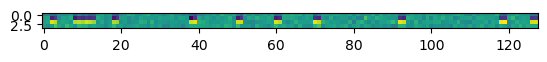

In [57]:
plt.imshow(B_fit_combined)

In [58]:
B_fit_combined.shape

(4, 128)

In [ ]:
# Get latent trajectories
params_fit_combined = make_params(C_fit_combined, jnp.exp(log_d_fit_combined), A_fit_combined, B_fit_combined)
posts_fit_combined = vmap(lambda obs, input: cmgs(params_fit_combined,   EKFIntegrals(), obs, inputs = input))(all_observations_combined, stim_ind_combined)
recon_all_combined = softplus(posts_fit_combined.filtered_means @ C_fit_combined.T + jnp.exp(log_d_fit_combined))
innovations_all_combined = all_observations_combined - recon_all_combined

In [16]:
t = jnp.arange(all_observations_combined.shape[1])
n_latents = posts_fit_combined.filtered_covariances.shape[-1]
colors = {"init": "b", "fit": "r"}
labels = {"init": "init params", "fit": "fitted params"}

U, S, Vt = jnp.linalg.svd(C_fit_combined, full_matrices=False)
R = Vt.T #@ jnp.diag(S)            # (latent_dim, latent_dim)

z_combined = posts_fit_combined.filtered_means @ R

# top_dims is trivially 0,1,2,... since SVD sorts descending
top_dims_rot = jnp.arange(n_latents)

## Split up control and stim

In [ ]:
control_mask = trial_labels == 0
stim_mask    = trial_labels == 1

# Split observations and inputs
all_observations_control = all_observations_combined[control_mask]
all_observations_stim    = all_observations_combined[stim_mask]
stim_ind_control_split   = stim_ind_combined[control_mask]
stim_ind_stim_split      = stim_ind_combined[stim_mask]

# Split posteriors and latents
posts_control = jax.tree.map(lambda x: x[control_mask], posts_fit_combined)
posts_stim    = jax.tree.map(lambda x: x[stim_mask],    posts_fit_combined)

z_control = z_combined[control_mask]
z_stim    = z_combined[stim_mask]

recon_control = recon_all_combined[control_mask]
recon_stim    = recon_all_combined[stim_mask]
innovations_control = innovations_all_combined[control_mask]
innovations_stim    = innovations_all_combined[stim_mask]

# Trial-averaged trajectories in SVD space
z_control_mean = jnp.mean(z_control, axis=0)  # (n_bins, state_dim)
z_stim_mean    = jnp.mean(z_stim,    axis=0)

## Plots

In [18]:
import plotly.graph_objects as go

def plot_latent_phase_portrait_shared(
    z_control,
    z_stim,
    centers_ms_control,
    centers_ms_stim,
    alpha_trials=0.15,
    stim_z1_offset=0.0
):
    ir_c = int(np.argmin(np.abs(centers_ms_control)))
    ir_s = int(np.argmin(np.abs(centers_ms_stim)))

    def unpack(z):
        m = z.mean(axis=0)
        return m[:, 0], m[:, 1], m[:, 2]

    x_c, y_c, zc = unpack(z_control)
    x_s, y_s, zs = unpack(z_stim)
    
    ctrl_color = "red"
    stim_color = "blue"

    fig = go.Figure()

    # control trials
    for trial in range(z_control.shape[0]):
        fig.add_trace(go.Scatter3d(
            x=z_control[trial, :, 0],
            y=z_control[trial, :, 1],
            z=z_control[trial, :, 2],
            mode="lines",
            line=dict(color=ctrl_color, width=1),
            opacity=alpha_trials,
            showlegend=False,
        ))

    fig.add_trace(go.Scatter3d(
        x=x_c, y=y_c, z=zc,
        mode="markers+lines",
        marker=dict(size=3, color=centers_ms_control, colorscale="Viridis", showscale=False),
        line=dict(color="red", width=3),
        name="control mean",
    ))

    # stim trials
    for trial in range(z_stim.shape[0]):
        fig.add_trace(go.Scatter3d(
            x=z_stim[trial, :, 0] + stim_z1_offset,
            y=z_stim[trial, :, 1],
            z=z_stim[trial, :, 2],
            mode="lines",
            line=dict(color=stim_color, width=1),
            opacity=alpha_trials,
            showlegend=False,
        ))

    fig.add_trace(go.Scatter3d(
        x=x_s + stim_z1_offset, y=y_s, z=zs,
        mode="markers+lines",
        marker=dict(size=3, color=centers_ms_stim, colorscale="Viridis", showscale=True,
                    colorbar=dict(title="Time (ms)", thickness=15, x=1.0)),
        line=dict(color="blue", width=3),
        name="stim mean",
    ))

    # reference markers
    fig.add_trace(go.Scatter3d(
        x=[x_c[0]], y=[y_c[0]], z=[zc[0]],
        mode="markers",
        marker=dict(size=6, color="green"),
        name="control start"
    ))

    fig.add_trace(go.Scatter3d(
        x=[x_c[ir_c]], y=[y_c[ir_c]], z=[zc[ir_c]],
        mode="markers",
        marker=dict(size=6, color="yellow"),
        name="control IR"
    ))

    fig.add_trace(go.Scatter3d(
        x=[x_s[ir_s] + stim_z1_offset], y=[y_s[ir_s]], z=[zs[ir_s]],
        mode="markers",
        marker=dict(size=6, color="orange"),
        name="stim IR"
    ))

    fig.update_layout(
        title="Control vs Stim latent trajectories",
        scene=dict(
            xaxis_title="z₁",
            yaxis_title="z₂",
            zaxis_title="z₃",
            aspectmode="cube"
        ),
        legend=dict(itemsizing="constant", x=1.15, y=0.4),
        margin=dict(l=0, r=0, b=0, t=40),
        width=1000,
        height=500,
    )

    return fig

NameError: name 'B' is not defined

In [19]:
fig = plot_latent_phase_portrait_shared(
    z_control=z_control,
    z_stim=z_stim,
    centers_ms_control=centers_ms_control,
    centers_ms_stim=centers_ms_stim,
    alpha_trials=0.05,
    stim_z1_offset=0.0
)

fig.update_layout(scene_camera=dict(
    eye=dict(x=1.75, y=0.75, z=0.75),
    center=dict(x=0, y=0, z=-0.2)
))

fig.show()

## EKF + SGD learning of Poisson LDS + perturb

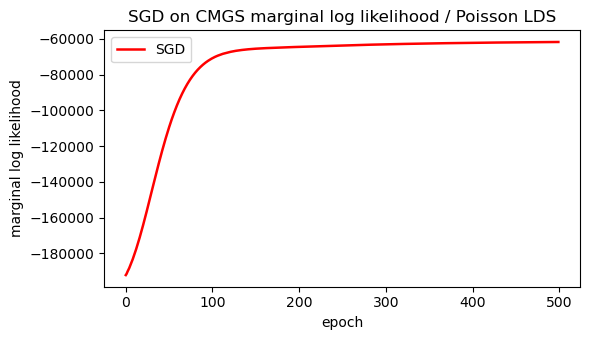

In [20]:
%matplotlib inline 
# Plot loss curve
plt.figure(figsize=(6, 3.5))
plt.plot(-jnp.array(losses), color="r", lw=1.8, label="SGD")
plt.xlabel("epoch"); plt.ylabel("marginal log likelihood")
plt.title("SGD on CMGS marginal log likelihood / Poisson LDS")
plt.legend(); plt.tight_layout()

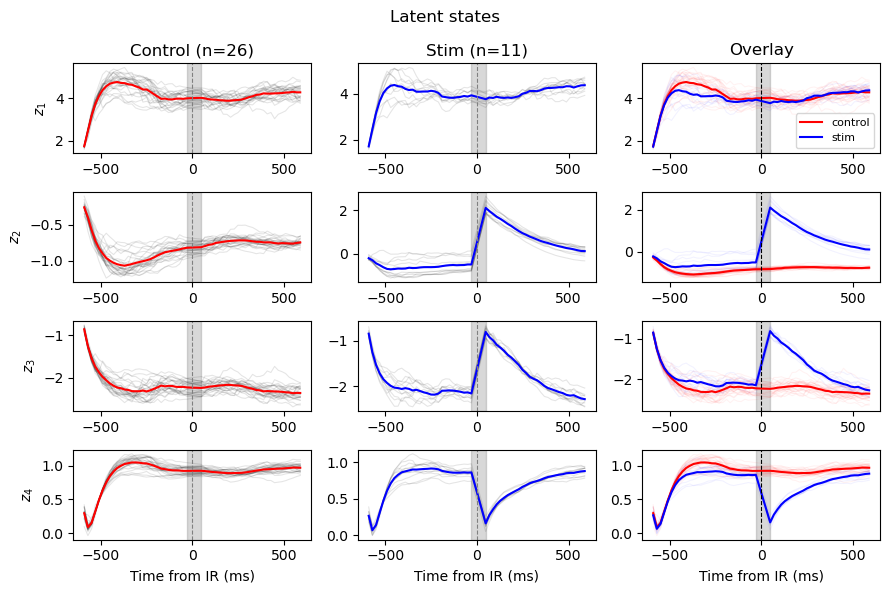

In [43]:
%matplotlib inline

disp_states = 4
disp_states = min(disp_states, z_combined.shape[-1])

n_trials_ctrl = z_control.shape[0]
n_trials_stim = z_stim.shape[0]

mean_ctrl = z_control.mean(axis=0)
mean_stim = z_stim.mean(axis=0)

fig, axs = plt.subplots(disp_states, 3, figsize=(9, 1.5 * disp_states), sharex=False)

for d in range(disp_states):
    # Control (left)
    ax_c = axs[d, 0]
    for i in range(n_trials_ctrl):
        ax_c.plot(centers_ms_control, z_control[i, :, d], color="k", lw=0.8, alpha=0.1)
    ax_c.plot(centers_ms_control, mean_ctrl[:, d], color="red", lw=1.5)
    ax_c.axvline(0, color="grey", lw=0.8, ls="--")
    ax_c.set_ylabel(rf"$z_{{{d+1}}}$")
    ax_c.axvspan(centers_ms_stim[ir_idx], centers_ms_stim[ir_idx + 1], color="grey", alpha=0.3)
    if d == 0:
        ax_c.set_title(f"Control (n={n_trials_ctrl})")
    if d == disp_states - 1:
        ax_c.set_xlabel("Time from IR (ms)")

    # Stim (middle)
    ax_s = axs[d, 1]
    for i in range(n_trials_stim):
        ax_s.plot(centers_ms_stim, z_stim[i, :, d], color="k", lw=0.8, alpha=0.1)
    ax_s.plot(centers_ms_stim, mean_stim[:, d], color="blue", lw=1.5)
    ax_s.axvline(0, color="grey", lw=0.8, ls="--")
    ax_s.axvspan(centers_ms_stim[ir_idx], centers_ms_stim[ir_idx + 1], color="grey", alpha=0.3)
    if d == 0:
        ax_s.set_title(f"Stim (n={n_trials_stim})")
    if d == disp_states - 1:
        ax_s.set_xlabel("Time from IR (ms)")

    # Overlay (right)
    ax_o = axs[d, 2]
    for i in range(n_trials_ctrl):
        ax_o.plot(centers_ms_control, z_control[i, :, d], color="red", lw=0.8, alpha=0.05)
    for i in range(n_trials_stim):
        ax_o.plot(centers_ms_stim, z_stim[i, :, d], color="blue", lw=0.8, alpha=0.05)
    ax_o.plot(centers_ms_control, mean_ctrl[:, d], color="red",  lw=1.5, label="control")
    ax_o.plot(centers_ms_stim,    mean_stim[:, d], color="blue", lw=1.5, label="stim")
    ax_o.axvline(0, color='k', lw=0.8, ls='--')
    ax_o.axvspan(centers_ms_stim[ir_idx], centers_ms_stim[ir_idx + 1], color="grey", alpha=0.3)
    if d == 0:
        ax_o.set_title("Overlay")
        ax_o.legend(fontsize=8)
    if d == disp_states - 1:
        ax_o.set_xlabel("Time from IR (ms)")

fig.suptitle("Latent states")
plt.tight_layout()

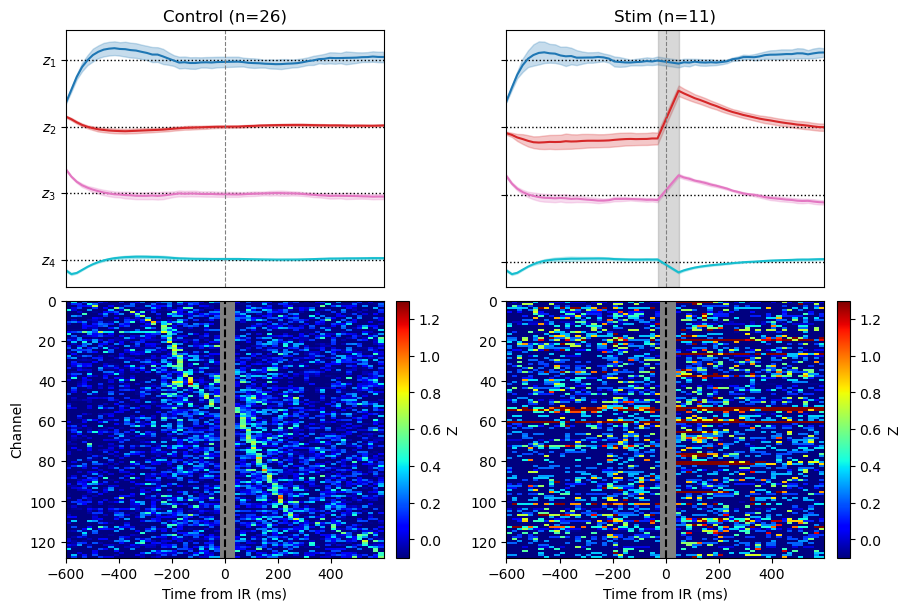

In [ ]:
def plot_mean_latents_and_psth(
    z_control, z_stim,
    psth_control, psth_stim,
    edges_ms_control, edges_ms_stim,
    centers_ms_control, centers_ms_stim, ir_idx,
    disp_states=5, vmin=None, vmax=None
):
    n_ch = psth_control.shape[0]
    y_edges = np.arange(n_ch + 1)

    mean_c = z_control.mean(axis=0)
    std_c  = z_control.std(axis=0)
    mean_s = z_stim.mean(axis=0)
    std_s  = z_stim.std(axis=0)

    states_all = np.concatenate([mean_c[:, :disp_states], mean_s[:, :disp_states]], axis=0)
    lim = 1.5 * abs(states_all - states_all.mean(axis=0)).max()
    colors = plt.cm.tab10(np.linspace(0, 1, disp_states))

    fig, axs = plt.subplots(
        2, 2,
        height_ratios=[disp_states, 4],
        figsize=(9, 1 * disp_states + 2),
        constrained_layout=True
    )

    for col, (mean_latents, std_latents, label, centers_ms) in enumerate([
        (mean_c, std_c, f"Control (n={z_control.shape[0]})", centers_ms_control),
        (mean_s, std_s, f"Stim (n={z_stim.shape[0]})",       centers_ms_stim),
    ]):
        ax = axs[0, col]
        for d in range(disp_states):
            offset = -lim * d
            c = colors[d]
            ax.axhline(offset, color='k', ls=':', lw=1)
            mean_d = mean_latents[:, d]
            std_d  = std_latents[:, d]
            mu_c   = mean_d - mean_d.mean()
            ax.fill_between(centers_ms, mu_c - std_d + offset, mu_c + std_d + offset,
                            color=c, alpha=0.25)
            ax.plot(centers_ms, mu_c + offset, color=c, lw=1.5)

        ax.set_yticks(-jnp.arange(disp_states) * lim)
        if col == 0:
            ax.set_yticklabels([rf"$z_{{{d+1}}}$" for d in range(disp_states)])
            ax.axvline(0, color='grey', lw=0.8, ls='--')
        else:
            ax.set_yticklabels([])
            ax.axvline(0, color='grey', lw=0.8, ls='--')
            ax.axvspan(centers_ms[ir_idx], centers_ms[ir_idx + 1], color="grey", alpha=0.3)
        ax.set_xticks([])
        ax.set_xlim(centers_ms[0], centers_ms[-1])
        ax.set_title(label)

    for col, (psth, edges_ms, centers_ms) in enumerate([
        (psth_control, edges_ms_control, centers_ms_control),
        (psth_stim,    edges_ms_stim,    centers_ms_stim),
    ]):
        ax_b = axs[1, col]
        ax_b.set_facecolor("0.5")
        pc = ax_b.pcolormesh(
            edges_ms, y_edges, psth,
            shading="flat", cmap="jet", vmin=vmin, vmax=vmax,
        )
        ax_b.invert_yaxis()
        ax_b.axvline(0, linestyle="--", color="black")
        ax_b.set_ylim(n_ch, 0)
        ax_b.set_xlim(edges_ms[0], edges_ms[-1])
        ax_b.set_xlabel("Time from IR (ms)")
        if col == 0:
            ax_b.set_ylabel("Channel")
        fig.colorbar(pc, ax=ax_b, label="Z", fraction=0.046, pad=0.04)


# counts_ch_control: (trials, n_ch, n_bins)
mu_control  = np.nanmean(counts_ch_control, axis=(0, 2), keepdims=False)  # (n_ch,)
sig_control = np.nanstd( counts_ch_control, axis=(0, 2), keepdims=False)  # (n_ch,)
sig_control = np.clip(sig_control, 1e-6, None)

counts_ch_stim_t = counts_ch_stim.transpose(0, 2, 1)  # (trials, n_bins, n_ch)
counts_ch_stim_zscored = (counts_ch_stim_t - mu_control[None, None, :]) / sig_control[None, None, :] # z-score each stim trial using control baseline
psth_z_stim = np.nanmean(counts_ch_stim_zscored, axis=0) # get average trace
psth_z_stim = psth_z_stim.T # transpose for plotting

psth_stim_sorted, _ = pad_bins_to_edges(psth_z_stim[order], centers_ms_stim, edges_ms_stim, tol=1e-3)

plot_mean_latents_and_psth(
    z_control=z_control,
    z_stim=z_stim,
    psth_control=psth_plot,
    psth_stim=psth_stim_sorted,
    edges_ms_control=edges_ms_control,
    edges_ms_stim=edges_ms_stim,
    centers_ms_control=centers_ms_control,
    centers_ms_stim=centers_ms_stim,
    ir_idx=ir_idx,
    disp_states=disp_states,
    vmin=-0.1, vmax=1.3
)

## Reconstruction error

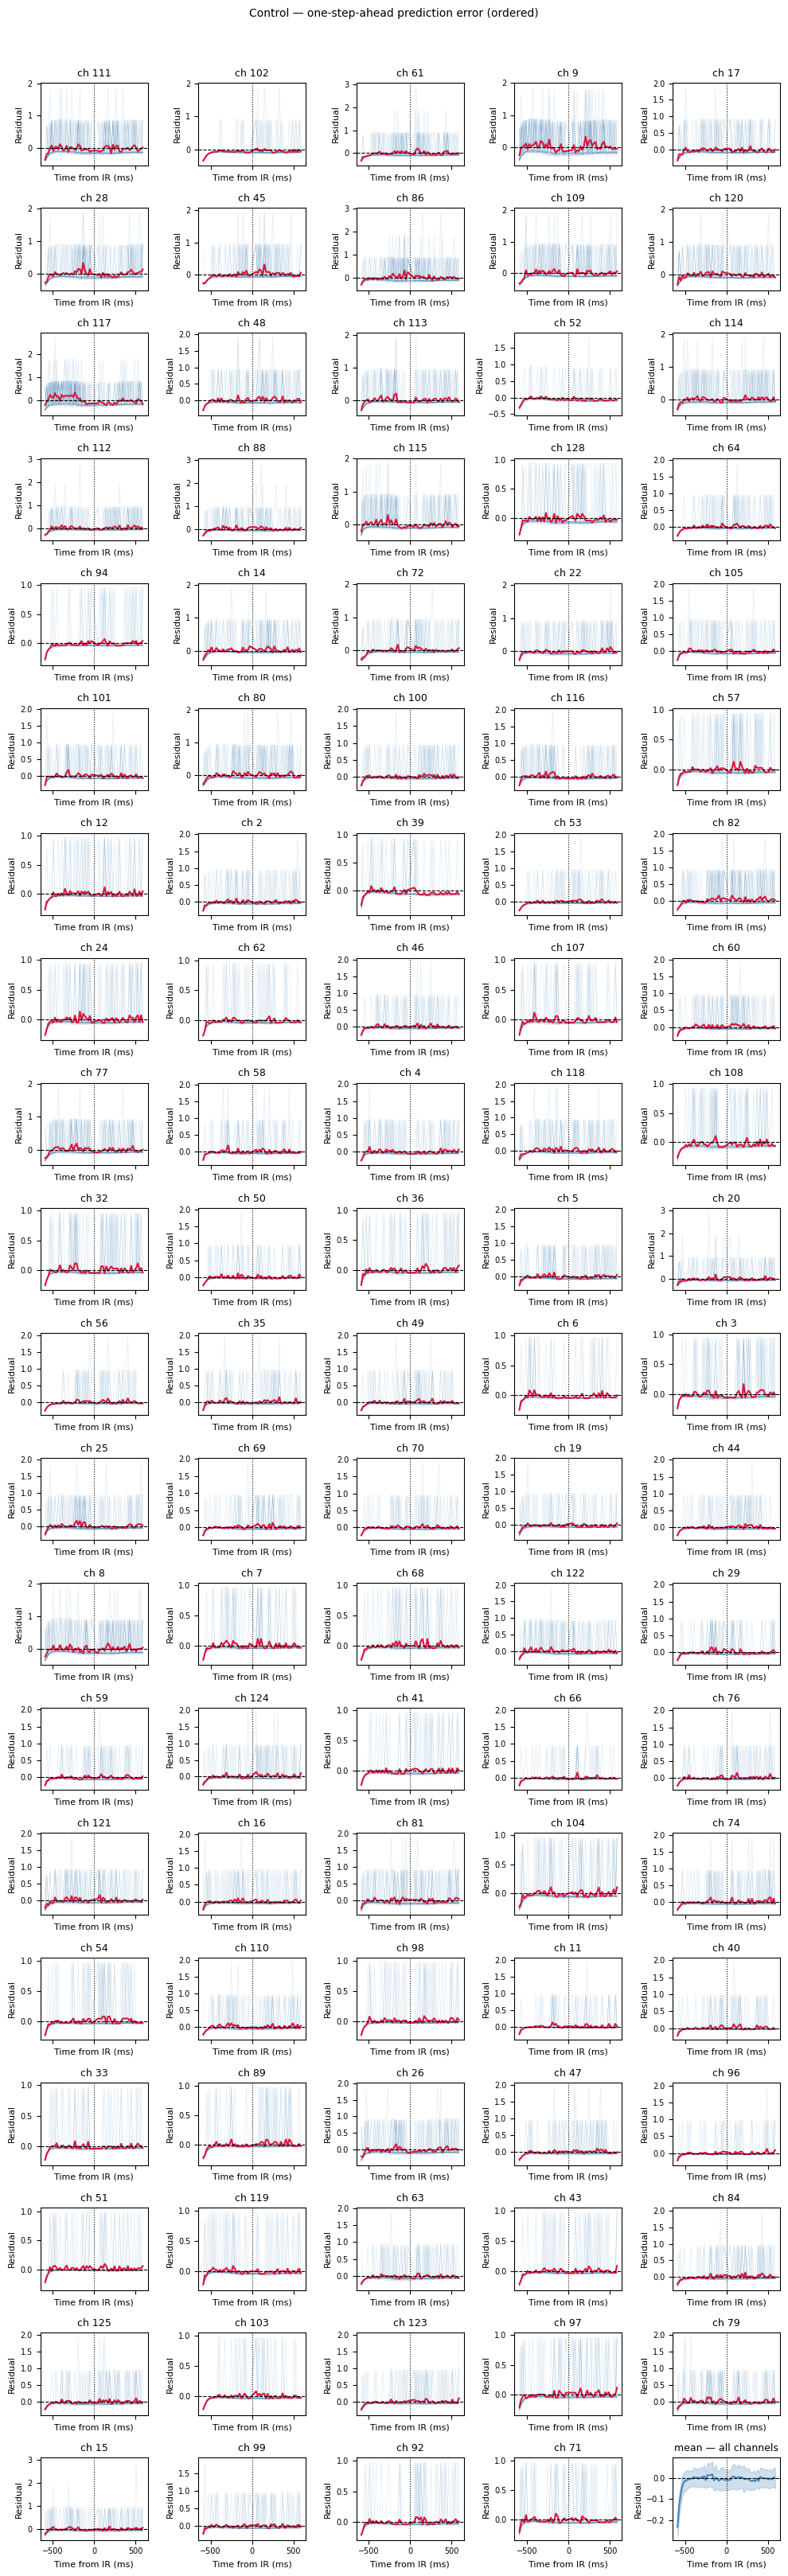

In [ ]:
n_trials, T, obs_dim = innovations_control.shape

mean_innovation = np.array(innovations_control.mean(axis=0))
innovations_np  = np.array(innovations_control)

channel_order = np.argsort(np.abs(mean_innovation).max(axis=0))[::-1]

fig, axes = plt.subplots(20, 5, figsize=(10, 32), sharex=True, sharey=False)
axes_flat = axes.flatten()

for plot_idx, ch in enumerate(channel_order[:99]):
    ax = axes_flat[plot_idx]
    for i in range(n_trials):
        ax.plot(centers_ms_control, innovations_np[i, :, ch],
                color='steelblue', alpha=0.15, linewidth=0.5)
    ax.plot(centers_ms_control, mean_innovation[:, ch],
            color='crimson', linewidth=1.5)
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='k', linewidth=0.8, linestyle=':')
    ax.set_title(f'ch {ch+1}', fontsize=9)

for ax in axes_flat:
    ax.set_xlabel('Time from IR (ms)', fontsize=8)
    ax.set_ylabel('Residual', fontsize=8)
    ax.tick_params(labelsize=7)

ax = axes_flat[-1]
mean_across = mean_innovation.mean(axis=-1)
std_across  = mean_innovation.std(axis=-1)
ax.fill_between(centers_ms_control,
                mean_across - std_across,
                mean_across + std_across,
                alpha=0.25, color='steelblue')
ax.plot(centers_ms_control, mean_across, color='steelblue', linewidth=1.5)
ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.axvline(0, color='k', linewidth=0.8, linestyle=':')
ax.set_title('mean — all channels', fontsize=9)

plt.suptitle('Control — one-step-ahead reconstruction error (ordered)', fontsize=10, y = 1.01)
plt.tight_layout()
plt.show()

In [52]:
stim_ind_stim[1, ir_idx, :]

Array([0., 0., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0.,
       0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       1., 0., 0., 0., 0., 0., 0., 1., 1.], dtype=float32)

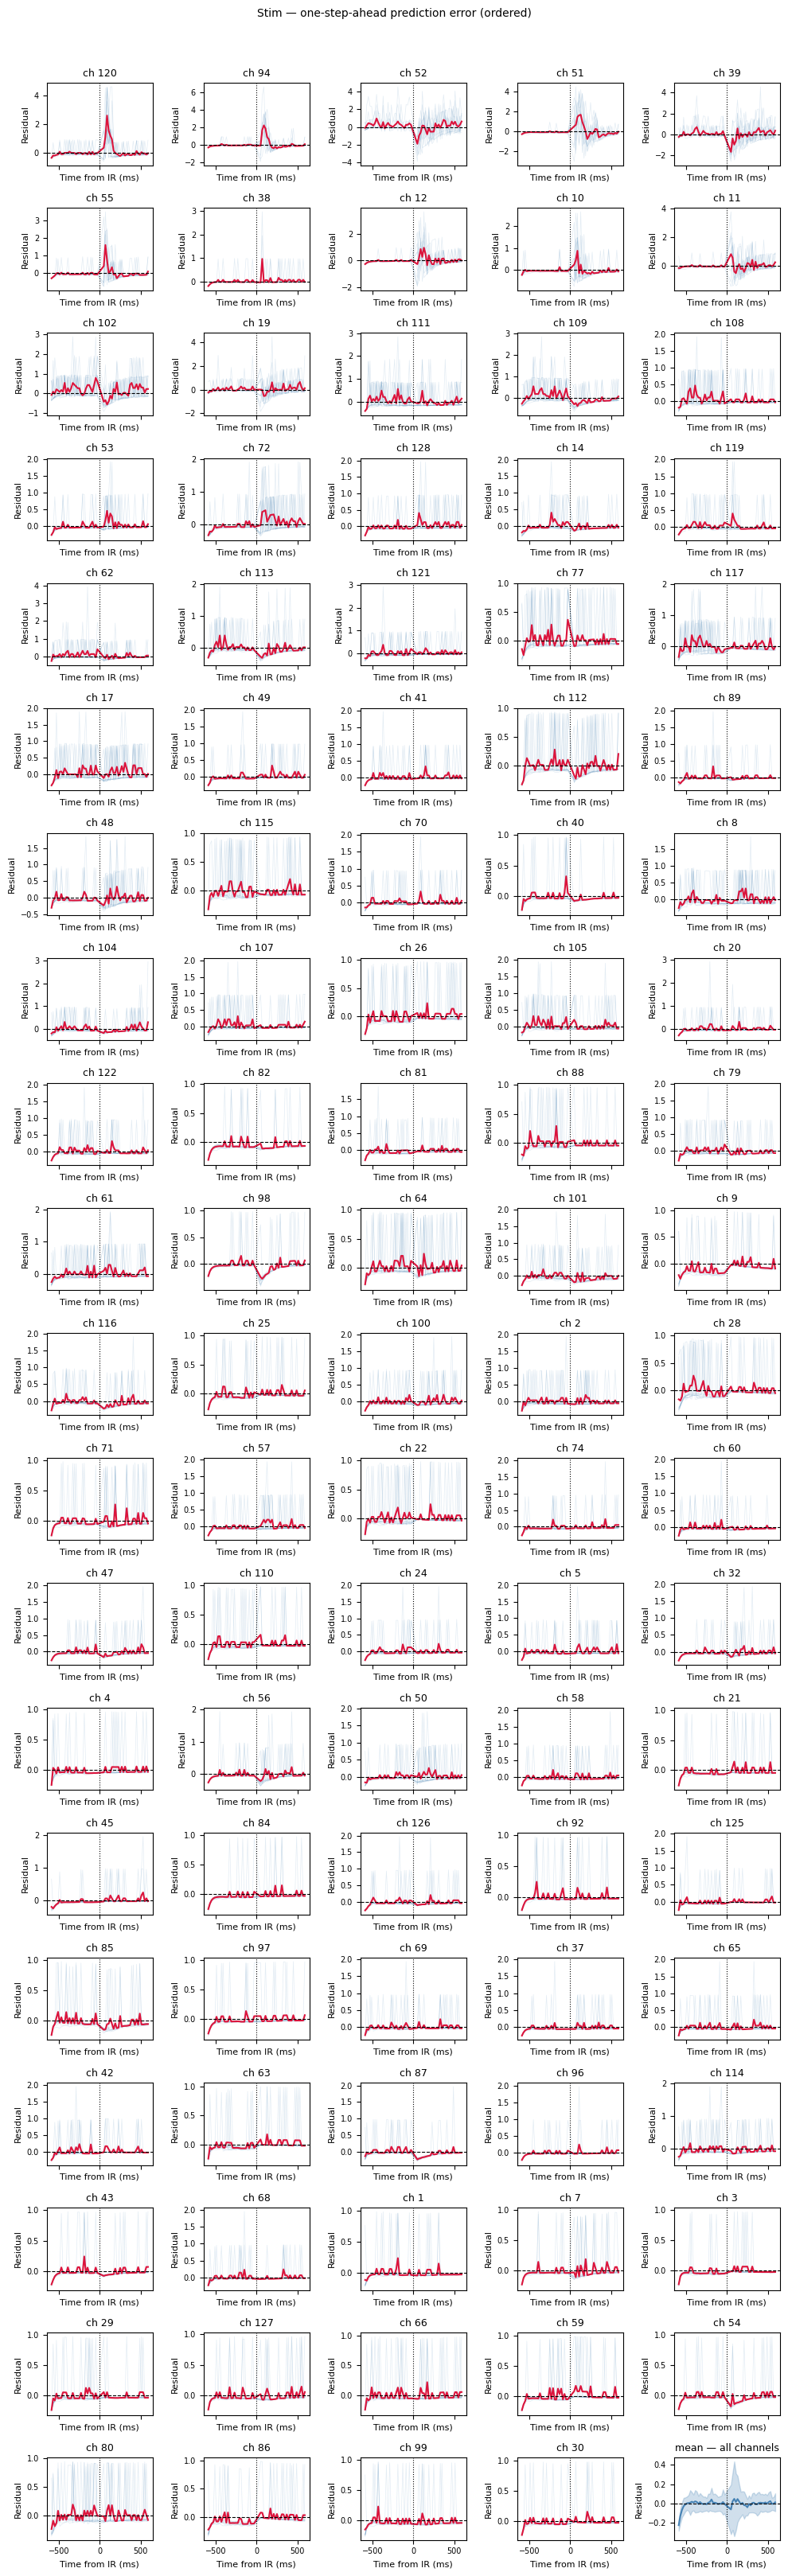

In [ ]:
n_trials, T, obs_dim = innovations_stim.shape

mean_innovation = np.array(innovations_stim.mean(axis=0))
innovations_np  = np.array(innovations_stim)

channel_order = np.argsort(np.abs(mean_innovation).max(axis=0))[::-1]

fig, axes = plt.subplots(20, 5, figsize=(10, 32), sharex=True, sharey=False)
axes_flat = axes.flatten()

for plot_idx, ch in enumerate(channel_order[:99]):
    ax = axes_flat[plot_idx]
    for i in range(n_trials):
        ax.plot(centers_ms_stim, innovations_np[i, :, ch],
                color='steelblue', alpha=0.15, linewidth=0.5)
    ax.plot(centers_ms_stim, mean_innovation[:, ch],
            color='crimson', linewidth=1.5)
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='k', linewidth=0.8, linestyle=':')
    ax.set_title(f'ch {ch+1}', fontsize=9)

for ax in axes_flat:
    ax.set_xlabel('Time from IR (ms)', fontsize=8)
    ax.set_ylabel('Residual', fontsize=8)
    ax.tick_params(labelsize=7)

ax = axes_flat[-1]
mean_across = mean_innovation.mean(axis=-1)
std_across  = mean_innovation.std(axis=-1)
ax.fill_between(centers_ms_stim,
                mean_across - std_across,
                mean_across + std_across,
                alpha=0.25, color='steelblue')
ax.plot(centers_ms_stim, mean_across, color='steelblue', linewidth=1.5)
ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.axvline(0, color='k', linewidth=0.8, linestyle=':')
ax.set_title('mean — all channels', fontsize=9)

plt.suptitle('Stim — one-step-ahead reconstruction error (ordered)', fontsize=10, y = 1.01)
plt.tight_layout()
plt.show()